<a href="https://colab.research.google.com/github/JorgeEncinas/pytorch_ztm/blob/main/05_pytorch_going_modular_exercises.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 05. PyTorch Going Modular Exercises

Welcome to the 05. PyTorch Going Modular exercise template notebook.

There are several questions in this notebook and it's your goal to answer them by writing Python and PyTorch code.

> **Note:** There may be more than one solution to each of the exercises, don't worry too much about the *exact* right answer. Try to write some code that works first and then improve it if you can.

## Resources and solutions

* These exercises/solutions are based on [section 05. PyTorch Going Modular](https://www.learnpytorch.io/05_pytorch_going_modular/) of the Learn PyTorch for Deep Learning course by Zero to Mastery.

**Solutions:**

Try to complete the code below *before* looking at these.

* See a live [walkthrough of the solutions (errors and all) on YouTube](https://youtu.be/ijgFhMK3pp4).
* See an example [solutions notebook for these exercises on GitHub](https://github.com/mrdbourke/pytorch-deep-learning/blob/main/extras/solutions/05_pytorch_going_modular_exercise_solutions.ipynb).

## 1. Turn the code to get the data (from section 1. Get Data) into a Python script, such as `get_data.py`.

* When you run the script using `python get_data.py` it should check if the data already exists and skip downloading if it does.
* If the data download is successful, you should be able to access the `pizza_steak_sushi` images from the `data` directory.

In [ ]:
import os
os.makedirs("going_modular")

In [ ]:
%%writefile going_modular/get_data.py
"""
Gets data from the pizza_steak_sushi.zip source and saves it into data_path
"""
import os
import zipfile
from pathlib import Path
import requests

THRESHOLD=5

# Setup path to data folder
data_path = Path("data/")
image_path = data_path / "pizza_steak_sushi"

def download_and_unzip_images():
  # Download pizza, steak, sushi data
  with open(data_path / "pizza_steak_sushi.zip", "wb") as f:
      request = requests.get("https://github.com/mrdbourke/pytorch-deep-learning/raw/main/data/pizza_steak_sushi.zip")
      print("Downloading pizza, steak, sushi data...")
      f.write(request.content)
  # Unzip pizza, steak, sushi data
  with zipfile.ZipFile(data_path / "pizza_steak_sushi.zip", "r") as zip_ref:
      print("Unzipping pizza, steak, sushi data...")
      zip_ref.extractall(image_path)
  # Remove zip file
  os.remove(data_path / "pizza_steak_sushi.zip")

# If the image folder doesn't exist, download it and prepare it...
if image_path.is_dir():
    print(f"{image_path} directory exists.")
else:
    print(f"Did not find {image_path} directory, creating one...")
    image_path.mkdir(parents=True, exist_ok=True)

#print(list(image_path.glob("*/*")))
if len(list(image_path.glob("*/*/*.jpg"))) < THRESHOLD: #if you find less than X images...
  download_and_unzip_images()
else:
  print(f"Images were already downloaded past the THRESHOLD set ({THRESHOLD}) /n Not downloading again.")

Overwriting going_modular/get_data.py


In [ ]:
# Example running of get_data.py
!python going_modular/get_data.py

data/pizza_steak_sushi directory exists.
Images were already downloaded past the THRESHOLD set (5) /n Not downloading again.


## 2. Use [Python's `argparse` module](https://docs.python.org/3/library/argparse.html) to be able to send the `train.py` custom hyperparameter values for training procedures.
* Add an argument flag for using a different:
  * Training/testing directory
  * Learning rate
  * Batch size
  * Number of epochs to train for
  * Number of hidden units in the TinyVGG model
    * Keep the default values for each of the above arguments as what they already are (as in notebook 05).
* For example, you should be able to run something similar to the following line to train a TinyVGG model with a learning rate of 0.003 and a batch size of 64 for 20 epochs: `python train.py --learning_rate 0.003 batch_size 64 num_epochs 20`.
* **Note:** Since `train.py` leverages the other scripts we created in section 05, such as, `model_builder.py`, `utils.py` and `engine.py`, you'll have to make sure they're available to use too. You can find these in the [`going_modular` folder on the course GitHub](https://github.com/mrdbourke/pytorch-deep-learning/tree/main/going_modular/going_modular).

In [ ]:
type(255.)

float

Note: I copy-pasted the other `%%writefile` modules from the 05 notebook, ran them, created the modules, and then just deleted the cell to avoid cluttering this Notebook.

In [ ]:
%%writefile going_modular/data_setup.py
"""
Contains functionality for creating PyTorch's DataLoaders for
Image Classification Data
"""
import os
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

NUM_WORKERS = os.cpu_count()

def create_dataloaders(
    train_dir: str,
    test_dir: str,
    transform: transforms.Compose,
    batch_size : int,
    num_workers : int = NUM_WORKERS
):
  """Creates training and testing DataLoaders

  Takes in the paths for the train and test directories and turns them into
  PyTorch Datasets, then into PyTorch DataLoaders

  Args:
    train_dir: Path to training directory
    test_dir: Path to testing directory
    transform: torchvision transforms to perform on Training and Testing data.
    batch_size: number of samples per batch in each of the DataLoaders
    num_workers: an integer for the number of workers per DataLoader

  Returns:
    A tuple of (train_dataloader, test_dataloader, class_names),
    where class_names is a list of the target classes.
  """
  # Use ImageFolder to create dataset(s)
  train_data = datasets.ImageFolder(root=train_dir, # target folder of images
                                    transform=transform) # transforms to perform on data (images)
                                    #target_transform=None) # transforms to perform on labels (if necessary)

  test_data = datasets.ImageFolder(root=test_dir,
                                  transform=transform)

  train_dataloader = DataLoader(dataset=train_data,
                              batch_size=batch_size, # how many samples per batch?
                              num_workers=num_workers, # how many subprocesses to use for data loading? (higher = more)
                              shuffle=True, # shuffle the data?
                              pin_memory=True)

  # `pin_memory`
  # Recommended to use automatic memory pinning, which enables fast data transfer to
  # CUDA-enabled GPUs
  # A lot of time will be spent transferring to GPU
  # So setting it to `True` enables pinning memory, keeping it in place in the GPU where possible
  # Instead of transferring, it will try to keep it permanently in GPU to train there.

  test_dataloader = DataLoader(dataset=test_data,
                              batch_size=batch_size,
                              num_workers=num_workers,
                              shuffle=False,  # don't usually need to shuffle testing data
                              pin_memory=True)

  class_names = train_data.classes
  return (train_dataloader, test_dataloader, class_names)

Writing going_modular/data_setup.py


In [ ]:
%%writefile going_modular/model_builder.py
"""
Contains PyTorch model code to instantiate a TinyVGG model from the CNN
Explainer website.
"""
import torch

from torch import nn

class TinyVGG(nn.Module):
  """Creates the TinyVGG architecture.

  Replicates the TinyVGG architecture from the CNN explainer website in PyTorch.
  See the original architecture here: https://poloclub.github.io/cnn-explainer/

  Args:
    input_shape: An integer indicating number of input channels.
    hidden_units: An integer indicating number of hidden units between layers.
    output_shape: An integer indicating number of output units.
  """
  def __init__(self, input_shape: int, hidden_units: int, output_shape: int) -> None:
      super().__init__()
      self.conv_block_1 = nn.Sequential(
          nn.Conv2d(in_channels=input_shape,
                    out_channels=hidden_units,
                    kernel_size=3, # how big is the square that's going over the image?
                    stride=1, # default
                    padding=0), # options = "valid" (no padding) or "same" (output has same shape as input) or int for specific number
          nn.ReLU(),
          nn.Conv2d(in_channels=hidden_units,
                    out_channels=hidden_units,
                    kernel_size=3,
                    stride=1,
                    padding=0),
          nn.ReLU(),
          nn.MaxPool2d(kernel_size=2,
                        stride=2) # default stride value is same as kernel_size
      )
      self.conv_block_2 = nn.Sequential(
          nn.Conv2d(hidden_units, hidden_units, kernel_size=3, padding=0),
          nn.ReLU(),
          nn.Conv2d(hidden_units, hidden_units, kernel_size=3, padding=0),
          nn.ReLU(),
          nn.MaxPool2d(2)
      )
      self.classifier = nn.Sequential(
          nn.Flatten(),
          # Where did this in_features shape come from?
          # It's because each layer of our network compresses and changes the shape of our inputs data.
          nn.Linear(in_features=hidden_units*13*13,
                    out_features=output_shape)
      )

  def forward(self, x: torch.Tensor):
      x = self.conv_block_1(x)
      x = self.conv_block_2(x)
      x = self.classifier(x)
      return x
      # return self.classifier(self.block_2(self.block_1(x))) # <- leverage the benefits of operator fusion

Writing going_modular/model_builder.py


In [ ]:
%%writefile going_modular/engine.py
"""
Contains functions for training and testing a PyTorch model
"""
#If you don't import whatever the functions need, you will get errors
from typing import Dict, List, Tuple
import torch
from tqdm.auto import tqdm

def train_step(model: torch.nn.Module,
               dataloader: torch.utils.data.DataLoader,
               loss_fn: torch.nn.Module,
               optimizer: torch.optim.Optimizer,
               device: torch.device) -> Tuple[float, float]:
  """Trains a PyTorch model for a single epoch.

  Turns a target PyTorch model to training mode and then
  runs through all of the required training steps (forward
  pass, loss calculation, optimizer step).

  Args:
    model: A PyTorch model to be trained.
    dataloader: A DataLoader instance for the model to be trained on.
    loss_fn: A PyTorch loss function to minimize.
    optimizer: A PyTorch optimizer to help minimize the loss function.
    device: A target device to compute on (e.g. "cuda" or "cpu").

  Returns:
    A tuple of training loss and training accuracy metrics.
    In the form (train_loss, train_accuracy). For example:

    (0.1112, 0.8743)
  """
  # Put model in train mode
  model.train()

  # Setup train loss and train accuracy values
  train_loss, train_acc = 0, 0

  # Loop through data loader data batches
  for batch, (X, y) in enumerate(dataloader):
      # Send data to target device
      X, y = X.to(device), y.to(device)

      # 1. Forward pass
      y_pred = model(X)

      # 2. Calculate  and accumulate loss
      loss = loss_fn(y_pred, y)
      train_loss += loss.item()

      # 3. Optimizer zero grad
      optimizer.zero_grad()

      # 4. Loss backward
      loss.backward()

      # 5. Optimizer step
      optimizer.step()

      # Calculate and accumulate accuracy metric across all batches
      y_pred_class = torch.argmax(torch.softmax(y_pred, dim=1), dim=1)
      train_acc += (y_pred_class == y).sum().item()/len(y_pred)

  # Adjust metrics to get average loss and accuracy per batch
  train_loss = train_loss / len(dataloader)
  train_acc = train_acc / len(dataloader)
  return train_loss, train_acc

def test_step(model: torch.nn.Module,
              dataloader: torch.utils.data.DataLoader,
              loss_fn: torch.nn.Module,
              device: torch.device) -> Tuple[float, float]:
  """Tests a PyTorch model for a single epoch.

  Turns a target PyTorch model to "eval" mode and then performs
  a forward pass on a testing dataset.

  Args:
    model: A PyTorch model to be tested.
    dataloader: A DataLoader instance for the model to be tested on.
    loss_fn: A PyTorch loss function to calculate loss on the test data.
    device: A target device to compute on (e.g. "cuda" or "cpu").

  Returns:
    A tuple of testing loss and testing accuracy metrics.
    In the form (test_loss, test_accuracy). For example:

    (0.0223, 0.8985)
  """
  # Put model in eval mode
  model.eval()

  # Setup test loss and test accuracy values
  test_loss, test_acc = 0, 0

  # Turn on inference context manager
  with torch.inference_mode():
      # Loop through DataLoader batches
      for batch, (X, y) in enumerate(dataloader):
          # Send data to target device
          X, y = X.to(device), y.to(device)

          # 1. Forward pass
          test_pred_logits = model(X)

          # 2. Calculate and accumulate loss
          loss = loss_fn(test_pred_logits, y)
          test_loss += loss.item()

          # Calculate and accumulate accuracy
          test_pred_labels = test_pred_logits.argmax(dim=1)
          test_acc += ((test_pred_labels == y).sum().item()/len(test_pred_labels))

  # Adjust metrics to get average loss and accuracy per batch
  test_loss = test_loss / len(dataloader)
  test_acc = test_acc / len(dataloader)
  return test_loss, test_acc

def train(model: torch.nn.Module,
          train_dataloader: torch.utils.data.DataLoader,
          test_dataloader: torch.utils.data.DataLoader,
          optimizer: torch.optim.Optimizer,
          loss_fn: torch.nn.Module,
          epochs: int,
          device: torch.device) -> Dict[str, List[float]]:
  """Trains and tests a PyTorch model.

  Passes a target PyTorch models through train_step() and test_step()
  functions for a number of epochs, training and testing the model
  in the same epoch loop.

  Calculates, prints and stores evaluation metrics throughout.

  Args:
    model: A PyTorch model to be trained and tested.
    train_dataloader: A DataLoader instance for the model to be trained on.
    test_dataloader: A DataLoader instance for the model to be tested on.
    optimizer: A PyTorch optimizer to help minimize the loss function.
    loss_fn: A PyTorch loss function to calculate loss on both datasets.
    epochs: An integer indicating how many epochs to train for.
    device: A target device to compute on (e.g. "cuda" or "cpu").

  Returns:
    A dictionary of training and testing loss as well as training and
    testing accuracy metrics. Each metric has a value in a list for
    each epoch.
    In the form: {train_loss: [...],
                  train_acc: [...],
                  test_loss: [...],
                  test_acc: [...]}
    For example if training for epochs=2:
                 {train_loss: [2.0616, 1.0537],
                  train_acc: [0.3945, 0.3945],
                  test_loss: [1.2641, 1.5706],
                  test_acc: [0.3400, 0.2973]}
  """
  # Create empty results dictionary
  results = {"train_loss": [],
      "train_acc": [],
      "test_loss": [],
      "test_acc": []
  }

  # Loop through training and testing steps for a number of epochs
  for epoch in tqdm(range(epochs)):
      train_loss, train_acc = train_step(model=model,
                                          dataloader=train_dataloader,
                                          loss_fn=loss_fn,
                                          optimizer=optimizer,
                                          device=device)
      test_loss, test_acc = test_step(model=model,
          dataloader=test_dataloader,
          loss_fn=loss_fn,
          device=device)

      # Print out what's happening
      print(
          f"Epoch: {epoch+1} | "
          f"train_loss: {train_loss:.4f} | "
          f"train_acc: {train_acc:.4f} | "
          f"test_loss: {test_loss:.4f} | "
          f"test_acc: {test_acc:.4f}"
      )

      # Update results dictionary
      results["train_loss"].append(train_loss)
      results["train_acc"].append(train_acc)
      results["test_loss"].append(test_loss)
      results["test_acc"].append(test_acc)

  # Return the filled results at the end of the epochs
  return results

Writing going_modular/engine.py


In [ ]:
%%writefile going_modular/utils.py

from pathlib import Path
import torch

def save_model(model: torch.nn.Module,
               target_dir: str,
               model_name: str):
  """Saves a PyTorch model to a target directory.

  Args:
    model: A target PyTorch model to save.
    target_dir: A directory for saving the model to.
    model_name: A filename for the saved model. Should include
      either ".pth" or ".pt" as the file extension.

  Example usage:
    save_model(model=model_0,
               target_dir="models",
               model_name="05_going_modular_tingvgg_model.pth")
  """
  # Create target directory
  target_dir_path = Path(target_dir)
  target_dir_path.mkdir(parents=True,
                        exist_ok=True)

  # Create model save path
  assert model_name.endswith(".pth") or model_name.endswith(".pt"), "model_name should end with '.pt' or '.pth'"
  model_save_path = target_dir_path / model_name

  # Save the model state_dict()
  print(f"[INFO] Saving model to: {model_save_path}")
  torch.save(obj=model.state_dict(),
             f=model_save_path)

Writing going_modular/utils.py


In [ ]:
%%writefile going_modular/train.py
"""
Trains a PyTorch image classification model using device-agnostic code.
"""

import os
import torch
from torch import nn
from timeit import default_timer as timer
from torchvision import transforms
import argparse
import data_setup, engine, model_builder, utils
# We're not saying `from going_modular`, since this module will be in that same folder

def run_train():
  # Setup directories
  train_dir = "data/pizza_steak_sushi/train"
  test_dir = "data/pizza_steak_sushi/test"

  # Setup device-agnostic code
  device = "cuda" if torch.cuda.is_available() else "cpu"

  # Create transforms
  data_transform = transforms.Compose([
      transforms.Resize(size=(64, 64)),
      transforms.ToTensor()
  ])

  train_dataloader, test_dataloader, class_names = data_setup.create_dataloaders(
      train_dir = train_dir,
      test_dir=test_dir,
      transform=data_transform,
      batch_size=BATCH_SIZE
      #num_workers=NUM_WORKERS #This one's automatically set using os.cpu_count()
  )
  print(class_names)

  # Create model
  model = model_builder.TinyVGG(
      input_shape=3,
      hidden_units=HIDDEN_UNITS,
      output_shape=len(class_names)
  ).to(device)

  # Setup loss and optimizer
  loss_fn = nn.CrossEntropyLoss()
  optimizer = torch.optim.Adam(
      params=model.parameters(),
      lr=LEARNING_RATE
  )

  start_time = timer()

  # Start training from engine.py
  results = engine.train(
      model=model,
      train_dataloader=train_dataloader,
      test_dataloader=test_dataloader,
      optimizer=optimizer,
      loss_fn=loss_fn,
      epochs=NUM_EPOCHS,
      device=device
  )

  end_time = timer()
  print(f"Training time: {end_time-start_time:.2f}")

  # Save model
  utils.save_model(
      model=model,
      target_dir="models",
      model_name="05_going_modular_script_mode_tinyvgg_model.pth"
  )

# Setup hyperparameters - these could be argument flags, using `argparse`
NUM_EPOCHS = 5
BATCH_SIZE=32
HIDDEN_UNITS=10
LEARNING_RATE=0.001

if __name__ == "__main__":
  parser = argparse.ArgumentParser()
  parser.add_argument("-e", "--num_epochs", type=int, help="How many epochs to train through, Default=5")
  parser.add_argument("-bs", "--batch_size", type=int, help="How many items per batch, Default=32")
  parser.add_argument("-hu", "--hidden_units", type=int, help="Number of hidden units per layer, Default=10")
  parser.add_argument("-lr", "--learning_rate", type=float, help="Adam Learning Rate, default=0.001")
  args = parser.parse_args()
  NUM_EPOCHS = args.num_epochs if args.num_epochs else NUM_EPOCHS
  BATCH_SIZE = args.batch_size if args.batch_size else BATCH_SIZE
  HIDDEN_UNITS = args.hidden_units if args.hidden_units else HIDDEN_UNITS
  LEARNING_RATE = args.learning_rate if args.learning_rate else LEARNING_RATE
  print(f"Your setup: \n Epochs:{NUM_EPOCHS} | BatchSize: {BATCH_SIZE} | HU: {HIDDEN_UNITS} | LR: {LEARNING_RATE}")
  run_train()

Overwriting going_modular/train.py


In [ ]:
# Example running of train.py
!python going_modular/train.py --num_epochs 5 --batch_size 128 --hidden_units 128 --learning_rate 0.0003

Your setup: 
 Epochs:5 | BatchSize: 128 | HU: 128 | LR: 0.0003
['pizza', 'steak', 'sushi']
  0% 0/5 [00:00<?, ?it/s]Epoch: 1 | train_loss: 1.1020 | train_acc: 0.2329 | test_loss: 1.0909 | test_acc: 0.3333
 20% 1/5 [00:35<02:23, 35.78s/it]Epoch: 2 | train_loss: 1.1018 | train_acc: 0.3334 | test_loss: 1.0936 | test_acc: 0.3333
 40% 2/5 [01:08<01:41, 33.80s/it]Epoch: 3 | train_loss: 1.0779 | train_acc: 0.4116 | test_loss: 1.0830 | test_acc: 0.4533
 60% 3/5 [01:37<01:03, 31.68s/it]Epoch: 4 | train_loss: 1.0583 | train_acc: 0.5598 | test_loss: 1.0509 | test_acc: 0.4800
 80% 4/5 [02:05<00:30, 30.28s/it]Epoch: 5 | train_loss: 1.0164 | train_acc: 0.6257 | test_loss: 1.0193 | test_acc: 0.4133
100% 5/5 [02:34<00:00, 30.86s/it]
Training time: 154.30
[INFO] Saving model to: models/05_going_modular_script_mode_tinyvgg_model.pth


## 3. Create a Python script to predict (such as `predict.py`) on a target image given a file path with a saved model.

* For example, you should be able to run the command `python predict.py some_image.jpeg` and have a trained PyTorch model predict on the image and return its prediction.
* To see example prediction code, check out the [predicting on a custom image section in notebook 04](https://www.learnpytorch.io/04_pytorch_custom_datasets/#113-putting-custom-image-prediction-together-building-a-function).
* You may also have to write code to load in a trained model.

In [ ]:
from going_modular import model_builder

In [ ]:
%%writefile going_modular/predict.py

import torch
from pathlib import Path
import argparse
import model_builder
import torchvision
from torchvision import transforms
import matplotlib.pyplot as plt

def predict_from_model(target_image_path : str):
  class_names = ["pizza", "steak", "sushi"]

  # Device
  device = "cuda" if torch.cuda.is_available() else "cpu"

  # Getting the saved model parameters and creating a new instance
  models_path = Path("models")
  model_filename = "05_going_modular_script_mode_tinyvgg_model.pth"
  model_save_path = models_path / model_filename
  model_state_dict = torch.load(f=model_save_path, weights_only=True)

  #This kind of isn't flexible, since I need input_shape, hidden_units, and output_shape to be according to the model
  model = model_builder.TinyVGG(
      input_shape=3,
      hidden_units=128,
      output_shape=3
  )
  model.load_state_dict(model_state_dict)

  #Loading the image into a tensor
  img = torchvision.io.read_image(
      path=target_image_path
  ).to(torch.float32)
  img /= 255.
  img = transforms.Compose([
      transforms.Resize((64, 64))
  ])(img)

  model.eval()
  with torch.inference_mode():
    y_logits = model(img.unsqueeze(dim=0).to(device))
    y_pred_probs = torch.softmax(y_logits, dim=1)
    y_preds = torch.argmax(y_pred_probs, dim=1).squeeze().item()
    plt.imshow(img.permute(1, 2, 0))
    plt.axis(False)
    prediction = f"Prediction: {class_names[y_preds]} | Probs: {y_pred_probs.squeeze()[y_preds]:.3f}"
    plt.title(prediction)
    print(f"Prediction: {class_names[y_preds]} | Probs: {y_pred_probs.squeeze()[y_preds]:.3f}")



if __name__ == "__main__":
  parser = argparse.ArgumentParser()
  parser.add_argument("-im", "--image", type=str, help="The complete path, including the root and the image filename")
  args = parser.parse_args()
  predict_from_model(target_image_path = args.image)


Overwriting going_modular/predict.py


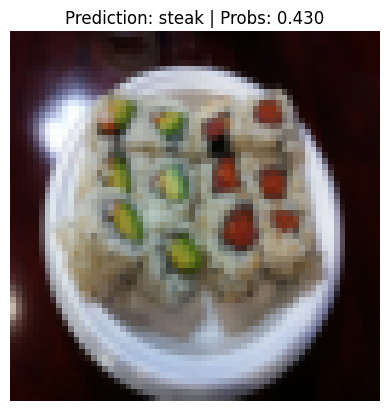

In [ ]:
predict_from_model("data/pizza_steak_sushi/test/sushi/175783.jpg")

In [ ]:
# Example running of predict.py
!python going_modular/predict.py --image data/pizza_steak_sushi/test/sushi/175783.jpg

Prediction: pizza | Probs: 0.404


# Metadata cleaning

In [ ]:
import nbformat

notebook_path = "/content/drive/MyDrive/Colab Notebooks/05_pytorch_going_modular_exercises.ipynb"

with open(notebook_path, 'r', encoding='utf-8') as f:
    nb = nbformat.read(f, as_version=4)

if 'widgets' in nb['metadata']:
    del nb['metadata']['widgets']
    print("Removed 'widgets' metadata.")
else:
    print("No 'widgets' metadata found.")

with open(notebook_path, 'w', encoding='utf-8') as f:
    nbformat.write(nb, f)
    print("Notebook cleaned and saved back to Drive.")


In [ ]:
from google.colab import drive
drive.mount('/content/drive')